In [1]:
from google.colab import files
uploaded = files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
%matplotlib inline

In [6]:
agri_df = pd.read_csv("agriculture_yield_dataset.csv")

In [7]:
# Part A: Understanding the Dataset
# Q1. Dataset Overview
print(agri_df.shape)
print(agri_df.columns)
display(agri_df.head(10))

(1500, 8)
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [8]:
# Q2. Data Types and Missing Values
print(agri_df.dtypes)
print(agri_df.isnull().sum())
missing = agri_df.isnull().sum()
print(missing[missing > 0])

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64
Series([], dtype: int64)


In [9]:
# Q3. Descriptive Statistics
stats = agri_df.describe()
print(stats)
print(stats.loc["mean"].idxmax())
print(stats.loc["std"].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

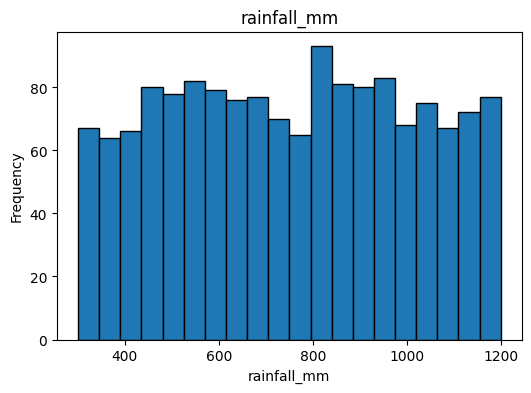

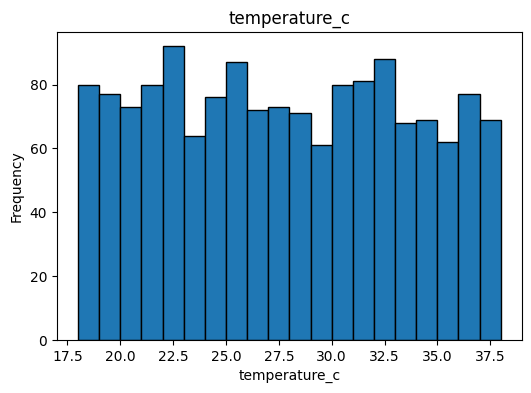

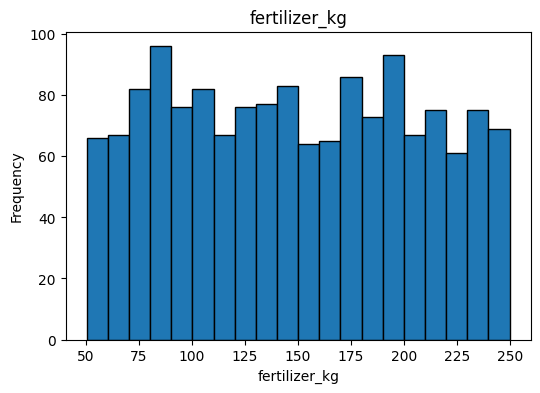

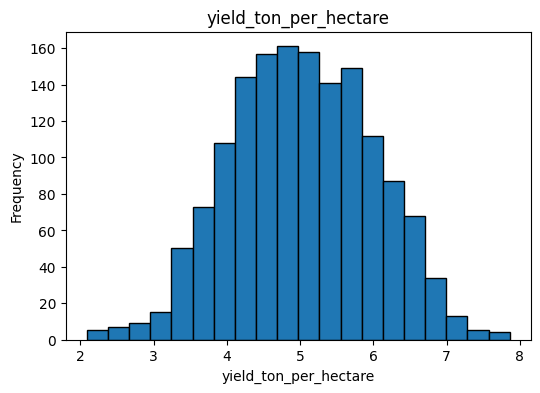

In [10]:
# Part B: Exploratory Data Analysis (EDA)
# Q4. Distribution Analysis
features = [
    "rainfall_mm",
    "temperature_c",
    "fertilizer_kg",
    "yield_ton_per_hectare"
]
for feature in features:
    plt.figure(figsize=(6,4))
    plt.hist(agri_df[feature], bins=20, edgecolor='black')
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

Rainfall Histogram

Rainfall values are distributed fairly evenly between approximately 300 mm and 1200 mm.
The histogram does not show significant skewness.
No noticeable outliers are present.

Temperature Histogram

Temperature values range from about 18°C to 38°C.
The distribution is nearly symmetric.
Most observations are concentrated around the middle values.

Fertilizer Histogram

Fertilizer usage is fairly evenly distributed.
There are no extreme peaks or gaps.
No significant outliers are observed.

Yield Histogram


Crop yield follows an approximately bell-shaped distribution.
Most yield values lie between 4 and 6 tons per hectare.
Very few extreme values are present.

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


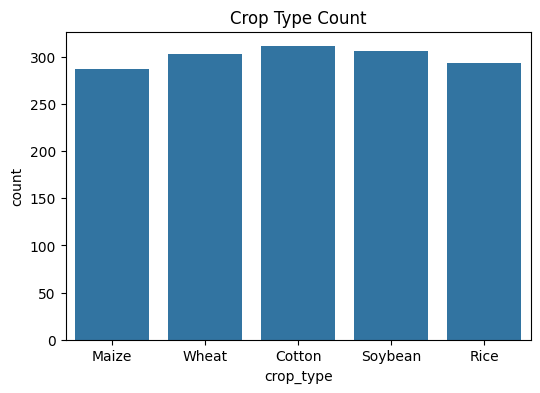

Most Frequent Crop:
Cotton


In [14]:
#Q5. Crop Type Analysis
print(agri_df["crop_type"].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(data=agri_df, x="crop_type")
plt.title("Crop Type Count")
plt.show()
print("Most Frequent Crop:")
print(agri_df["crop_type"].value_counts().idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


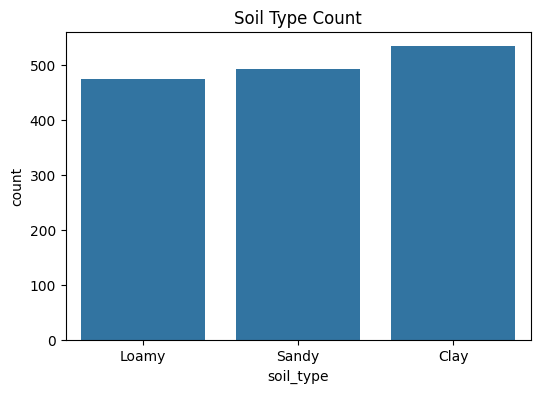

Most Common Soil Type:
Clay


In [15]:
# Q6. Soil Type Analysis
print(agri_df["soil_type"].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(data=agri_df, x="soil_type")
plt.title("Soil Type Count")
plt.show()
print("Most Common Soil Type:")
print(agri_df["soil_type"].value_counts().idxmax())

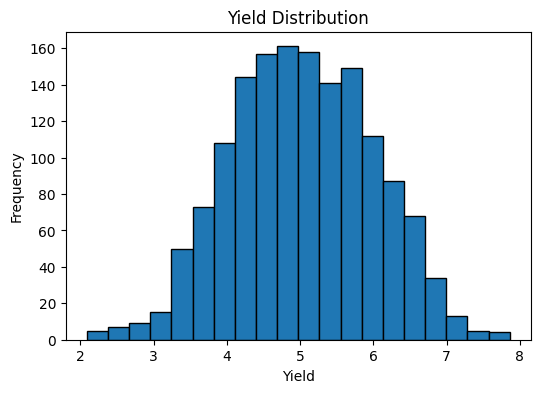

In [16]:
#Q7. Yield Distribution
plt.figure(figsize=(6,4))
plt.hist(agri_df["yield_ton_per_hectare"], bins=20, edgecolor="black")
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

The distribution is approximately normal.

No noticeable outliers are observed.

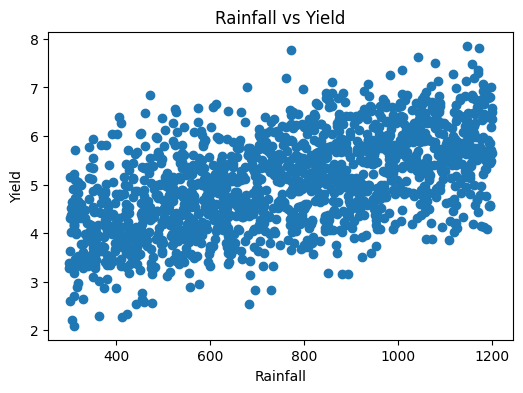

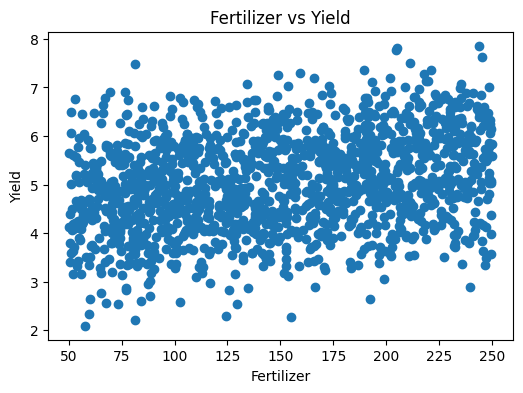

In [17]:
#Q8. Scatter Plot Analysis
#Rainfall vs Yield
plt.figure(figsize=(6,4))
plt.scatter(
    agri_df["rainfall_mm"],
    agri_df["yield_ton_per_hectare"]
)
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()
#Fertilizer vs Yield
plt.figure(figsize=(6,4))
plt.scatter(
    agri_df["fertilizer_kg"],
    agri_df["yield_ton_per_hectare"]
)
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

Rainfall appears to have a stronger relationship with crop yield than fertilizer.

As rainfall increases, crop yield generally tends to increase.

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

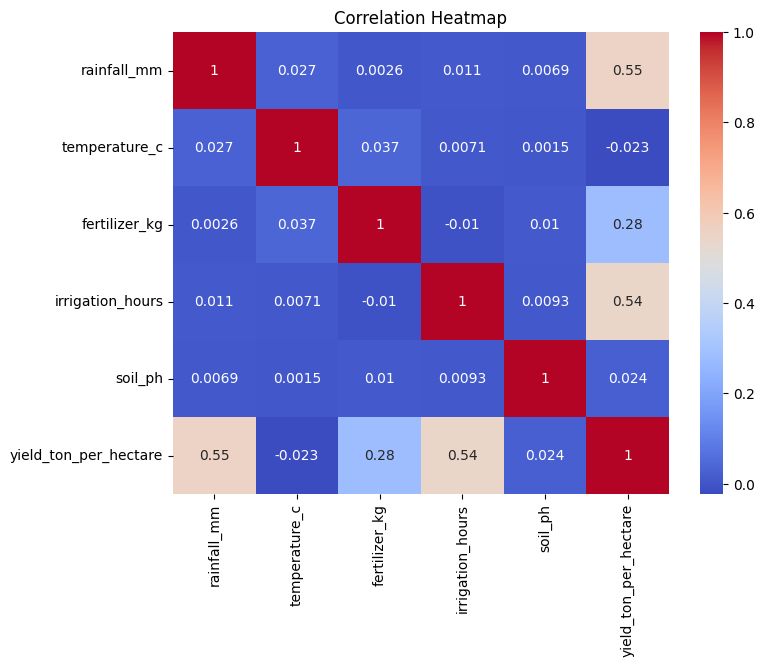

Top Features Correlated with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [18]:
#Q9. Correlation Analysis
corr = agri_df.corr(numeric_only=True)
print(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
print("Top Features Correlated with Yield:")
yield_corr = corr["yield_ton_per_hectare"].sort_values(ascending=False)
print(yield_corr)

Top three features most correlated with crop yield:

rainfall_mm

irrigation_hours

fertilizer_kg

In [19]:
#Q10. Group-Based Analysis
#Average Yield by Crop
crop_avg = agri_df.groupby("crop_type")["yield_ton_per_hectare"].mean()
print(crop_avg)
print("Highest Average Yield Crop:")
print(crop_avg.idxmax())
#Average Yield by Soil
soil_avg = agri_df.groupby("soil_type")["yield_ton_per_hectare"].mean()
print(soil_avg)
print("Highest Average Yield Soil:")
print(soil_avg.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
Highest Average Yield Crop:
Rice
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Highest Average Yield Soil:
Loamy


In [20]:
#Part C: Data Preparation
#Q11. Feature Encoding
categorical_cols = agri_df.select_dtypes(include="object").columns
print("Categorical Columns:")
print(categorical_cols)
agri_encoded = pd.get_dummies(
    agri_df,
    columns=categorical_cols,
    drop_first=True
)
display(agri_encoded.head())

Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [22]:
#Q12. Feature Selection
X = agri_encoded.drop("yield_ton_per_hectare", axis=1)
y = agri_encoded["yield_ton_per_hectare"]
print("Target Variable:")
print(y.name)
print("Features:")
display(X.head())

Target Variable:
yield_ton_per_hectare
Features:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,False,False,False,False,False,False


In [24]:
#Q13. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


In [25]:
#Q14. Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
#Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
display(coef_df)
print("Intercept:")
print(model.intercept_)
#Highest Positive Coefficient
highest = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)
print("Feature with Highest Positive Coefficient:")
display(highest.head(1))

,Feature,Coefficient
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
2,fertilizer_kg,0.004978
3,irrigation_hours,0.198327
4,soil_ph,0.004901
5,crop_type_Maize,0.238931
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974


Intercept:
1.587132027736121
Feature with Highest Positive Coefficient:


,Feature,Coefficient
6,crop_type_Rice,0.863993
